In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class JobState(TypedDict):
    job_description: str
    cleaned_text: str

    skills: list[str]
    experience: str
    education: str

    combined_info: dict
    job_summary: str

In [13]:
## preprocess_text

def preprocess_text(state: JobState):

    text = state["job_description"]

    # Basic preprocessing
    cleaned_text = " ".join(text.lower().split())

    return {
        "cleaned_text": cleaned_text
    }

In [14]:
## extract skills

def extract_skills(state: JobState):
    text = state["cleaned_text"]
    possible_skills = [
        "python",
        "java",
        "sql",
        "machine learning",
        "deep learning",
        "tensorflow",
        "pytorch",
        "docker",
        "aws",
        "git"
    ]
    skills = [
        skill
        for skill in possible_skills
        if skill in text
    ]
    return {
        "skills": skills
    }

In [15]:
## extract experience

def extract_experience(state: JobState):
    text = state["cleaned_text"]
    experience = "Not specified"
    if "2 years" in text:
        experience = "2+ years"
    elif "3 years" in text:
        experience = "3+ years"
    elif "1 year" in text:
        experience = "1+ year"
    elif "fresher" in text:
        experience = "Fresher"
    elif "entry level" in text:
        experience = "Entry-level"
    return {
        "experience": experience
    }


In [16]:
## extraxt education

def extract_education(state: JobState):
    text = state["cleaned_text"]
    education = "Not specified"
    if "b.tech" in text or "bachelor" in text:
        education = "Bachelor's degree / B.Tech"
    elif "m.tech" in text or "master" in text:
        education = "Master's degree / M.Tech"
    elif "phd" in text:
        education = "PhD"
    return {
        "education": education
    }

In [17]:
## combine_information

def combine_information(state: JobState):
    combined_info = {
        "skills": state["skills"],
        "experience": state["experience"],
        "education": state["education"]
    }
    return {
        "combined_info": combined_info
    }

In [8]:
## generate_job_summary

def generate_job_summary(state: JobState):
    info = state["combined_info"]
    skills = ", ".join(info["skills"])
    summary = f"""
Job Summary
-----------

Required Skills:
{skills}

Experience:
{info["experience"]}

Education:
{info["education"]}
"""
    return {
        "job_summary": summary
    }

In [ ]:
### create graph
graph = StateGraph(JobState)

In [ ]:
# Add nodes

graph.add_node("preprocess_text",preprocess_text)
graph.add_node("extract_skills",extract_skills)
graph.add_node("extract_experience",extract_experience)
graph.add_node("extract_education",extract_education)
graph.add_node("combine_information",combine_information)
graph.add_node("generate_job_summary",generate_job_summary)

In [ ]:
## Add edges

graph.add_edge(START,"preprocess_text")
graph.add_edge("preprocess_text","extract_skills")
graph.add_edge("preprocess_text","extract_experience")
graph.add_edge("preprocess_text","extract_education")

graph.add_edge("extract_skills","combine_information")
graph.add_edge("extract_experience","combine_information")
graph.add_edge("extract_education","combine_information")

graph.add_edge("combine_information","generate_job_summary")
graph.add_edge("generate_job_summary",END)


Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [ ]:
app = graph.compile()


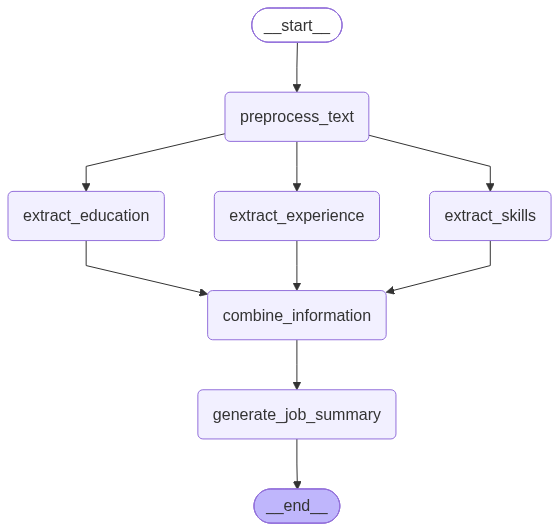

In [20]:
## workflow visualization

from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
## initial state
initial_state = {
    "job_description": """
    We are looking for a Machine Learning Engineer with
    2 years of experience.

    The candidate should have strong knowledge of Python,
    SQL, Machine Learning, Deep Learning, TensorFlow,
    Docker and Git.

    Bachelor's degree in Computer Science, Engineering,
    or a related field is required.
    """
}

In [22]:
result = app.invoke(initial_state)

In [23]:
print(result)

{'job_description': "\n    We are looking for a Machine Learning Engineer with\n    2 years of experience.\n\n    The candidate should have strong knowledge of Python,\n    SQL, Machine Learning, Deep Learning, TensorFlow,\n    Docker and Git.\n\n    Bachelor's degree in Computer Science, Engineering,\n    or a related field is required.\n    ", 'cleaned_text': "we are looking for a machine learning engineer with 2 years of experience. the candidate should have strong knowledge of python, sql, machine learning, deep learning, tensorflow, docker and git. bachelor's degree in computer science, engineering, or a related field is required.", 'skills': ['python', 'sql', 'machine learning', 'deep learning', 'tensorflow', 'docker', 'git'], 'experience': '2+ years', 'education': "Bachelor's degree / B.Tech", 'combined_info': {'skills': ['python', 'sql', 'machine learning', 'deep learning', 'tensorflow', 'docker', 'git'], 'experience': '2+ years', 'education': "Bachelor's degree / B.Tech"}, 'jo